In [5]:
import pandas as pd
import numpy as np

In [6]:
# FIX 1: Use a relative/shared path so the notebook works on any machine
df = pd.read_csv(r"D:\laper men\datathon_dani\inflasiwatch\data\final\output_clean\df_clean.csv")

In [7]:
df

,date,kota,month,month_sin,month_cos,ihk_kel_01_mtm,ihk_kel_03_mtm,ihk_kel_06_mtm,gt_harga_beras,gt_harga_cabai,...,gt_harga_bensin_lag3_pct_change,kota_jakarta,kota_makassar,kota_medan,kota_surabaya,ihk_umum_mtm,inflasi_general_mtm,inflasi_core_mtm,inflasi_administered_price_mtm,inflasi_volatile_good_mtm
0,2020-02-01,bandung,2,8.660254e-01,5.000000e-01,1.28,0.05,-0.72,51,42,...,-0.111111,0,0,0,0,0.32,0.28,0.14,-0.11,1.27
1,2020-03-01,bandung,3,1.000000e+00,6.120000e-17,0.95,0.00,-0.60,57,34,...,-0.111111,0,0,0,0,0.01,0.10,0.29,-0.19,-0.38
2,2020-04-01,bandung,4,8.660254e-01,-5.000000e-01,0.41,0.00,-0.38,87,50,...,-0.111111,0,0,0,0,-0.16,0.08,0.17,-0.14,-0.09
3,2020-05-01,bandung,5,5.000000e-01,-8.660254e-01,-0.97,0.00,0.12,78,42,...,-0.111111,0,0,0,0,0.21,0.07,0.06,0.67,-0.50
4,2020-06-01,bandung,6,1.220000e-16,-1.000000e+00,1.43,0.00,0.34,70,36,...,-0.093750,0,0,0,0,0.28,0.18,0.02,0.22,0.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,2025-11-01,surabaya,11,-5.000000e-01,8.660254e-01,0.37,0.01,0.53,40,51,...,-0.085714,0,0,0,1,0.21,0.17,0.17,0.24,0.02
366,2025-12-01,surabaya,12,-2.450000e-16,1.000000e+00,1.96,0.33,1.48,39,49,...,0.000000,0,0,0,1,0.80,0.64,0.20,0.37,2.74
367,2026-01-01,surabaya,1,5.000000e-01,8.660254e-01,-1.36,0.00,-0.95,45,45,...,0.250000,0,0,0,1,-0.16,-0.15,0.37,-0.32,-1.96
368,2026-02-01,surabaya,2,8.660254e-01,5.000000e-01,2.54,0.19,0.88,62,51,...,0.375000,0,0,0,1,0.99,0.68,0.42,-0.03,2.50


In [8]:
df_final = pd.get_dummies(df, columns=['kota'], drop_first=True)

# FIX 2: pd.get_dummies returns bool columns in newer pandas.
# Convert them to int so XGBoost and other models accept them.
bool_cols = df_final.select_dtypes('bool').columns.tolist()
df_final[bool_cols] = df_final[bool_cols].astype(int)

In [9]:
df_final['date'] = pd.to_datetime(df_final['date'])

In [10]:
# FIX 3: The original code did   df.final = pd.DataFrame(df_final)
# which sets an *attribute* on the df object (pandas even warns about it)
# and does NOT update df_final. The line is not needed — df_final is
# already a DataFrame. Removed.
df_final.head()

,date,month,month_sin,month_cos,ihk_kel_01_mtm,ihk_kel_03_mtm,ihk_kel_06_mtm,gt_harga_beras,gt_harga_cabai,gt_harga_telur,...,kota_surabaya,ihk_umum_mtm,inflasi_general_mtm,inflasi_core_mtm,inflasi_administered_price_mtm,inflasi_volatile_good_mtm,kota_jakarta,kota_makassar,kota_medan,kota_surabaya
0,2020-02-01,2,8.660254e-01,5.000000e-01,1.28,0.05,-0.72,51,42,76,...,0,0.32,0.28,0.14,-0.11,1.27,0,0,0,0
1,2020-03-01,3,1.000000e+00,6.120000e-17,0.95,0.00,-0.60,57,34,65,...,0,0.01,0.10,0.29,-0.19,-0.38,0,0,0,0
2,2020-04-01,4,8.660254e-01,-5.000000e-01,0.41,0.00,-0.38,87,50,89,...,0,-0.16,0.08,0.17,-0.14,-0.09,0,0,0,0
3,2020-05-01,5,5.000000e-01,-8.660254e-01,-0.97,0.00,0.12,78,42,99,...,0,0.21,0.07,0.06,0.67,-0.50,0,0,0,0
4,2020-06-01,6,1.220000e-16,-1.000000e+00,1.43,0.00,0.34,70,36,100,...,0,0.28,0.18,0.02,0.22,0.77,0,0,0,0


In [11]:
# FIX 4: The original used iloc[:,-1] to pick the last column, which
# became 'kota_surabaya' (a bool dummy) AFTER get_dummies reordered columns.
# Select the target by name to be safe.
TARGET = 'inflasi_volatile_good_mtm'

y = df_final[TARGET]
X = df_final.drop(columns=[TARGET])

In [12]:
split = int(len(y) * 0.8)
y_train, y_test = y[:split], y[split:]
X_train, X_test = X.iloc[:split, :], X.iloc[split:, :]

In [13]:
X_train

,date,month,month_sin,month_cos,ihk_kel_01_mtm,ihk_kel_03_mtm,ihk_kel_06_mtm,gt_harga_beras,gt_harga_cabai,gt_harga_telur,...,kota_medan,kota_surabaya,ihk_umum_mtm,inflasi_general_mtm,inflasi_core_mtm,inflasi_administered_price_mtm,kota_jakarta,kota_makassar,kota_medan,kota_surabaya
0,2020-02-01,2,8.660254e-01,5.000000e-01,1.2800,0.05,-0.72,51,42,76,...,0,0,0.32,0.28,0.14,-0.11,0,0,0,0
1,2020-03-01,3,1.000000e+00,6.120000e-17,0.9500,0.00,-0.60,57,34,65,...,0,0,0.01,0.10,0.29,-0.19,0,0,0,0
2,2020-04-01,4,8.660254e-01,-5.000000e-01,0.4100,0.00,-0.38,87,50,89,...,0,0,-0.16,0.08,0.17,-0.14,0,0,0,0
3,2020-05-01,5,5.000000e-01,-8.660254e-01,-0.9700,0.00,0.12,78,42,99,...,0,0,0.21,0.07,0.06,0.67,0,0,0,0
4,2020-06-01,6,1.220000e-16,-1.000000e+00,1.4300,0.00,0.34,70,36,100,...,0,0,0.28,0.18,0.02,0.22,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,2025-11-01,11,-5.000000e-01,8.660254e-01,-1.2200,0.00,1.74,46,37,39,...,0,0,0.21,0.17,0.17,0.24,0,0,0,0
292,2025-12-01,12,-2.450000e-16,1.000000e+00,3.3341,0.00,-0.90,83,50,47,...,0,0,0.80,0.64,0.20,0.37,0,0,0,0
293,2026-01-01,1,5.000000e-01,8.660254e-01,-2.6300,0.00,0.26,47,40,43,...,0,0,-0.16,-0.15,0.37,-0.32,0,0,0,0
294,2026-02-01,2,8.660254e-01,5.000000e-01,0.3100,0.01,0.28,70,39,50,...,0,0,0.99,0.68,0.42,-0.03,0,0,0,0


## ARIMA / SARIMAX

In [14]:
# pip install pmdarima

In [15]:
from pmdarima import auto_arima

# FIX 5: 'surpress_warnings' was a typo — the correct kwarg is 'suppress_warnings'
model_autoarima = auto_arima(
    y_train,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,   # <-- fixed spelling
    stepwise=True
)

print(model_autoarima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=963.890, Time=2.14 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=991.337, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=983.568, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=985.179, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1005.944, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=971.846, Time=1.22 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=971.437, Time=1.09 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=959.269, Time=3.89 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=965.438, Time=3.27 sec
 ARIMA(2,0,2)(2,0,2)[12] intercept   : AIC=953.755, Time=5.77 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=inf, Time=4.77 sec
 ARIMA(1,0,2)(2,0,2)[12] intercept   : AIC=964.946, Time=2.71 sec
 ARIMA(2,0,1)(2,0,2)[12] intercept   : AIC=967.223, Time=3.74 sec
 ARIMA(3,0,2)(2,0,2)[12] intercept   : AIC=924.374, Time=6.14 sec
 ARIMA(3,0,2)(1,0,2)[12] intercept  

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    order=model_autoarima.order,
    seasonal_order=model_autoarima.seasonal_order
)

result = model.fit()

d:\laper men\campeones\datasets\dac-unimed\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
fc = result.forecast(steps=len(y_test))

In [18]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

mae  = mean_absolute_error(y_test, fc)
mape = mean_absolute_percentage_error(y_test, fc)
rmse = root_mean_squared_error(y_test, fc)

print(f"MAE  SARIMAX: {mae:.4f}")
print(f"MAPE SARIMAX: {mape:.4f}")
print(f"RMSE SARIMAX: {rmse:.4f}")

MAE  SARIMAX: 1.0431
MAPE SARIMAX: 1.6673
RMSE SARIMAX: 1.3064


## Prophet

In [19]:
# pip install prophet

In [20]:
from prophet import Prophet

# FIX 6: Avoid PerformanceWarning from highly-fragmented df.
# Build the prophet frame from df_final (which is already a clean copy)
# instead of inserting new columns into the original df.
prophet_df = df_final[['date', TARGET]].rename(columns={'date': 'ds', TARGET: 'y'}).sort_values('ds')

split_p = int(0.8 * len(prophet_df))
train_p = prophet_df.iloc[:split_p]
test_p  = prophet_df.iloc[split_p:]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model_prophet.fit(train_p)

future   = model_prophet.make_future_dataframe(periods=len(test_p), freq='ME')
forecast = model_prophet.predict(future)

y_pred_p = forecast['yhat'].iloc[-len(test_p):].values
y_true_p = test_p['y'].values

print("MAE  Prophet:", round(mean_absolute_error(y_true_p, y_pred_p), 4))
print("MAPE Prophet:", round(mean_absolute_percentage_error(y_true_p, y_pred_p), 4))
print("RMSE Prophet:", round(root_mean_squared_error(y_true_p, y_pred_p), 4))

d:\laper men\campeones\datasets\dac-unimed\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
11:59:59 - cmdstanpy - INFO - Chain [1] start processing
12:00:00 - cmdstanpy - INFO - Chain [1] done processing


MAE  Prophet: 1.4716
MAPE Prophet: 5.1925
RMSE Prophet: 1.855


## XGBoost

In [21]:
from xgboost import XGBRegressor

# FIX 7: Drop 'date' (non-numeric) from features before fitting.
# FIX 8: Pass .values (numpy arrays) to XGBRegressor to avoid an
#         AttributeError in XGBoost >= 2 with pandas >= 2.
X_train_xgb = X_train.drop(columns=['date'])
X_test_xgb  = X_test.drop(columns=['date'])

xgbr = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgbr.fit(X_train_xgb.values, y_train.values)
y_pred_xgb = xgbr.predict(X_test_xgb.values)

print("MAE  XGBRegressor (Baseline):", round(mean_absolute_error(y_test, y_pred_xgb), 4))
print("MAPE XGBRegressor (Baseline):", round(mean_absolute_percentage_error(y_test, y_pred_xgb), 4))
print("RMSE XGBRegressor (Baseline):", round(root_mean_squared_error(y_test, y_pred_xgb), 4))

MAE  XGBRegressor (Baseline): 0.0874
MAPE XGBRegressor (Baseline): 0.4794
RMSE XGBRegressor (Baseline): 0.1386


## XGBoost — Optuna Hyperparameter Tuning

In [22]:
# FIX 9: The objektif() function was incomplete — it built params but
# never created a model, trained, or returned a score. Completed below.
import optuna
from sklearn.model_selection import cross_val_score

X_all = X.drop(columns=['date']).values
y_all = y.values

def objektif(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth":        trial.suggest_int("max_depth", 2, 6),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
    }
    model = XGBRegressor(**params)
    # Use negative MAE as the objective (higher = better for Optuna)
    scores = cross_val_score(model, X_all, y_all, cv=5,
                             scoring='neg_mean_absolute_error')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objektif, n_trials=50, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", round(-study.best_value, 4))

[I 2026-04-29 12:00:05,451] A new study created in memory with name: no-name-36ce99ed-3379-4573-a864-9513ea6762ad
Best trial: 0. Best value: -0.233994:   2%|▏         | 1/50 [00:03<02:28,  3.03s/it]

[I 2026-04-29 12:00:08,476] Trial 0 finished with value: -0.23399404254466033 and parameters: {'n_estimators': 424, 'learning_rate': 0.15855413371962507, 'max_depth': 4, 'subsample': 0.6705052006119715, 'colsample_bytree': 0.832463951483581, 'min_child_weight': 9, 'gamma': 1.771442365939082}. Best is trial 0 with value: -0.23399404254466033.


Best trial: 0. Best value: -0.233994:   4%|▍         | 2/50 [00:04<01:54,  2.38s/it]

[I 2026-04-29 12:00:10,399] Trial 1 finished with value: -0.2372199806387511 and parameters: {'n_estimators': 147, 'learning_rate': 0.06561417746267276, 'max_depth': 6, 'subsample': 0.9358639347692407, 'colsample_bytree': 0.7811225730433548, 'min_child_weight': 8, 'gamma': 1.9663312324322335}. Best is trial 0 with value: -0.23399404254466033.


Best trial: 0. Best value: -0.233994:   6%|▌         | 3/50 [00:08<02:06,  2.69s/it]

...

[I 2026-04-29 12:01:49,562] Trial 47 finished with value: -0.14557639910506615 and parameters: {'n_estimators': 454, 'learning_rate': 0.08105636551139718, 'max_depth': 4, 'subsample': 0.9443897299837539, 'colsample_bytree': 0.6201318378496913, 'min_child_weight': 3, 'gamma': 0.24305201293946702}. Best is trial 23 with value: -0.1336749597859846.


Best trial: 23. Best value: -0.133675:  98%|█████████▊| 49/50 [01:46<00:02,  2.19s/it]

[I 2026-04-29 12:01:51,688] Trial 48 finished with value: -0.17880683481410095 and parameters: {'n_estimators': 440, 'learning_rate': 0.08426237095979866, 'max_depth': 4, 'subsample': 0.9462310153566712, 'colsample_bytree': 0.6149483142235534, 'min_child_weight': 3, 'gamma': 0.7268811996639538}. Best is trial 23 with value: -0.1336749597859846.


Best trial: 23. Best value: -0.133675: 100%|██████████| 50/50 [01:48<00:00,  2.17s/it]

[I 2026-04-29 12:01:53,762] Trial 49 finished with value: -0.1473490360368144 and parameters: {'n_estimators': 463, 'learning_rate': 0.08989018603123994, 'max_depth': 4, 'subsample': 0.9802125213870618, 'colsample_bytree': 0.6679044300367873, 'min_child_weight': 2, 'gamma': 0.24280358060058232}. Best is trial 23 with value: -0.1336749597859846.
Best params: {'n_estimators': 291, 'learning_rate': 0.1795886005130558, 'max_depth': 4, 'subsample': 0.9920823890377883, 'colsample_bytree': 0.6014838604254966, 'min_child_weight': 5, 'gamma': 0.0019897384442827265}
Best CV MAE: 0.1337


In [23]:
# Train final tuned model on train split, evaluate on test split
best_xgbr = XGBRegressor(**study.best_params, random_state=42)
best_xgbr.fit(X_train_xgb.values, y_train.values)
y_pred_best = best_xgbr.predict(X_test_xgb.values)

print("MAE  XGBRegressor (Tuned):", round(mean_absolute_error(y_test, y_pred_best), 4))
print("MAPE XGBRegressor (Tuned):", round(mean_absolute_percentage_error(y_test, y_pred_best), 4))
print("RMSE XGBRegressor (Tuned):", round(root_mean_squared_error(y_test, y_pred_best), 4))

MAE  XGBRegressor (Tuned): 0.1034
MAPE XGBRegressor (Tuned): 0.6692
RMSE XGBRegressor (Tuned): 0.1476


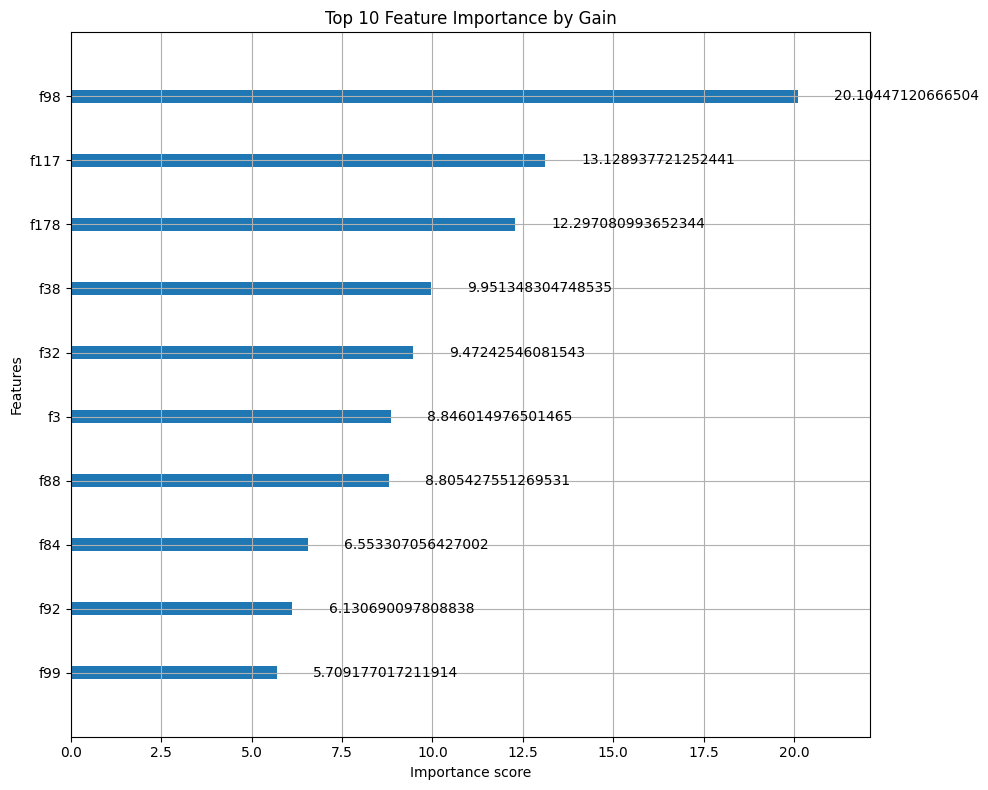

In [27]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(10, 8))

plot_importance(best_xgbr, 
                importance_type='gain', 
                max_num_features=10,
                ax=ax,
                title='Top 10 Feature Importance by Gain')

plt.tight_layout()
plt.show()

# LSTM

In [26]:
# ── Three-way split: train / val / test ──────────────────────────────────────
n = len(y)
train_end = int(n * 0.64)   # 64 % -> train
val_end   = int(n * 0.80)   # 16 % -> validation  (weight tuning)
                             # 20 % -> test         (final evaluation)

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

print(f"Train : {len(y_train):>4} rows  (idx  0 - {train_end-1})")
print(f"Val   : {len(y_val):>4} rows  (idx {train_end} - {val_end-1})")
print(f"Test  : {len(y_test):>4} rows  (idx {val_end} - {n-1})")

Train :  236 rows  (idx  0 - 235)
Val   :   60 rows  (idx 236 - 295)
Test  :   74 rows  (idx 296 - 369)


In [ ]:
# ── Auto ARIMA on train set ───────────────────────────────────────────────────
print("Running auto_arima ... (this may take ~30 s)")
model_aa = auto_arima(
    y_train,
    seasonal=True,
    m=12,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(f"Best order          : {model_aa.order}")
print(f"Best seasonal order : {model_aa.seasonal_order}")

In [ ]:
# ── Fit SARIMAX on train, predict val ─────────────────────────────────────────
sarimax_model = SARIMAX(
    y_train,
    order=model_aa.order,
    seasonal_order=model_aa.seasonal_order
)
sarimax_result = sarimax_model.fit(disp=False)
pred_sarimax_val = sarimax_result.forecast(steps=len(y_val))

# Refit on train+val to predict test (avoids leakage into weight optimisation)
sarimax_model2 = SARIMAX(
    pd.concat([y_train, y_val]),
    order=model_aa.order,
    seasonal_order=model_aa.seasonal_order
)
sarimax_result2   = sarimax_model2.fit(disp=False)
pred_sarimax_test = sarimax_result2.forecast(steps=len(y_test))

print(f"SARIMAX  MAE on val  : {mean_absolute_error(y_val,  pred_sarimax_val):.4f}")
print(f"SARIMAX  MAE on test : {mean_absolute_error(y_test, pred_sarimax_test):.4f}")

In [ ]:
# ── Fit XGBoost on train, predict val ─────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train.values, y_train.values)
pred_xgb_val = xgb_model.predict(X_val.values)

# Refit on train+val for test prediction
xgb_model2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model2.fit(
    np.vstack([X_train.values, X_val.values]),
    np.concatenate([y_train.values, y_val.values])
)
pred_xgb_test = xgb_model2.predict(X_test.values)

print(f"XGBoost  MAE on val  : {mean_absolute_error(y_val,  pred_xgb_val):.4f}")
print(f"XGBoost  MAE on test : {mean_absolute_error(y_test, pred_xgb_test):.4f}")

In [ ]:
# ── Grid search over w on validation set ─────────────────────────────────────
weights  = np.linspace(0, 1, 101)          # 0.00, 0.01, ..., 1.00
val_maes = [
    mean_absolute_error(y_val, w * pred_sarimax_val + (1 - w) * pred_xgb_val)
    for w in weights
]

# Exact optimum via bounded scalar minimisation
def ensemble_mae(w):
    return mean_absolute_error(y_val, w * pred_sarimax_val + (1 - w) * pred_xgb_val)

opt    = minimize_scalar(ensemble_mae, bounds=(0, 1), method='bounded')
w_opt  = opt.x
w_xgb  = 1 - w_opt

print(f"Optimal SARIMAX weight : {w_opt:.4f}  ({w_opt*100:.1f} %)")
print(f"Optimal XGBoost weight : {w_xgb:.4f}  ({w_xgb*100:.1f} %)")
print(f"MAE on val (ensemble)  : {opt.fun:.4f}")

In [ ]:
# ── Plot: MAE vs ensemble weight ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(weights, val_maes, color='#2563eb', linewidth=2, label='Ensemble MAE (val)')
ax.axvline(w_opt, color='#dc2626', linestyle='--', linewidth=1.5,
           label=f'Optimal w_SARIMAX = {w_opt:.2f}')
ax.axhline(mean_absolute_error(y_val, pred_sarimax_val), color='#059669',
           linestyle=':', linewidth=1.4, label='SARIMAX alone')
ax.axhline(mean_absolute_error(y_val, pred_xgb_val), color='#d97706',
           linestyle=':', linewidth=1.4, label='XGBoost alone')

ax.set_xlabel('w  (weight given to SARIMAX)', fontsize=11)
ax.set_ylabel('MAE on validation set', fontsize=11)
ax.set_title('Ensemble weight search — validation MAE', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Apply optimal weights to held-out test set ────────────────────────────────
pred_ensemble_test = w_opt * pred_sarimax_test + w_xgb * pred_xgb_test

def metrics(y_true, y_pred, label):
    return {
        'Model': label,
        'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        'MAPE':  round(mean_absolute_percentage_error(y_true, y_pred), 4),
        'RMSE':  round(root_mean_squared_error(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    metrics(y_test, pred_sarimax_test,  'SARIMAX'),
    metrics(y_test, pred_xgb_test,      'XGBoost'),
    metrics(y_test, pred_ensemble_test, f'Ensemble (w={w_opt:.2f}/{w_xgb:.2f})'),
]).set_index('Model')

print(results.to_string())